<a href="https://colab.research.google.com/github/AdamHopkinss/DD2365/blob/main/Lab%204%20Fluid-structure%20interaction/Mandatory_assignment_Elasticity_report_Elasticity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Elasticity equations**
**Johan Hoffman**


Adam Hopkins

# **Abstract**

This short report show an example on how to use FEniCS to solve the Elasticity equations, which is used in the course DD2365 Advanced Computation in Fluid Mechanics, at the KTH Royal Institute of Technology.

[DD2365 course website.](https://kth.instructure.com/courses/17071)

#### Conclusion of experiments:

For this model to produce physically meaningful results, the mesh must represent a reasonably elastic material, i.e. the Poisson's ratio should be kept within realistic values, such as $\nu = 0.3$, typical for materials like steel. Additionally, the prescribed displacements should remain small relative to the size of the domain. Too big displacements results in too large mesh distortions, or deformation patterns that are not physically possible in a two-dimensional setting.

# **About the code**

In [97]:
"""This program is an example file for the course"""
"""DD2365 Advanced Computation in Fluid Mechanics, """
"""KTH Royal Institute of Technology, Stockholm, Sweden."""

# Copyright (C) 2021 Johan Hoffman (jhoffman@kth.se)

# This file is part of the course DD2365 Advanced Computation in Fluid Mechanics
# KTH Royal Institute of Technology, Stockholm, Sweden
#
# This is free software: you can redistribute it and/or modify
# it under the terms of the GNU Lesser General Public License as published by
# the Free Software Foundation, either version 3 of the License, or
# (at your option) any later version.

# This template is maintained by Johan Hoffman
# Please report problems to jhoffman@kth.se

'KTH Royal Institute of Technology, Stockholm, Sweden.'

# **Set up environment**

In [98]:
# Load neccessary modules.
from google.colab import files

import numpy as np
import time

# Install FEniCS (this may take a long time)
try:
    import dolfin
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/fenics-install-release-real.sh" -O "/tmp/fenics-install.sh" && bash "/tmp/fenics-install.sh"
    import dolfin

from dolfin import *; from mshr import *

import dolfin.common.plotting as fenicsplot

from matplotlib import pyplot as plt

# **Introduction**

The Elasticity equations take the form

$-\nabla \cdot \sigma = f$

together with suitable boundary conditions.

To derive the weak form of the equations, multiply the equation by $v\in V$, and then integrate over the domain $\Omega$ and use Green's formula
$
(-\nabla \cdot \sigma ,v) = (\nabla \sigma , \nabla v)
- <\sigma \cdot n, v>_{\Gamma}
$

To model

We seek a finite element approximation $u\in V$ such that

$(\nabla \sigma,\nabla v) - <\sigma \cdot n, v>_{\partial \Omega} = (f,v)$

for all test functions $v \in V$.



# **Method**

**Define domain and mesh**

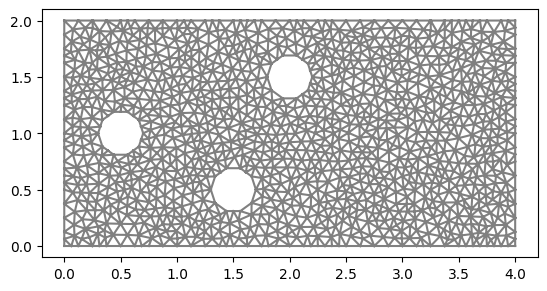

In [99]:
# Define rectangular domain
L = 4.0
H = 2.0

# Define subdomains (for boundary conditions)
class Left(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], 0.0)

class Right(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[0], L)

class Lower(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], 0.0)

class Upper(SubDomain):
    def inside(self, x, on_boundary):
        return near(x[1], H)

left = Left()
right = Right()
lower = Lower()
upper = Upper()

# Generate mesh (examples with and without a hole in the mesh)
resolution = 32
mesh = generate_mesh(Rectangle(Point(0.0,0.0), Point(L,H)) - Circle(Point(1.5,0.25*H),0.2) - Circle(Point(0.5,0.5*H),0.2) - Circle(Point(2.0,0.75*H),0.2), resolution)

# Local mesh refinement (specified by a cell marker)
no_levels = 0
for i in range(0,no_levels):
  cell_marker = MeshFunction("bool", mesh, mesh.topology().dim())
  for cell in cells(mesh):
    cell_marker[cell] = False
    p = cell.midpoint()
    if p.distance(Point(1.5, 0.5)) < 1.0:
        cell_marker[cell] = True
  mesh = refine(mesh, cell_marker)

# Define mesh functions (for boundary conditions)
boundaries = MeshFunction("size_t", mesh, mesh.topology().dim()-1)
boundaries.set_all(0)
left.mark(boundaries, 1)
right.mark(boundaries, 2)
lower.mark(boundaries, 3)
upper.mark(boundaries, 4)

plt.figure()
plot(mesh)
plt.show()

**Define finite element approximation spaces**

In [100]:
# Generate finite element space
VE = VectorElement("CG", mesh.ufl_cell(), 1)

V = FunctionSpace(mesh, VE)

# Define trial and test functions
u = TrialFunction(V)
v = TestFunction(V)

d = Function(V)

**Define boundary conditions**

In [101]:
# Define boundary conditions
class DirichletBoundaryLower(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], 0.0)

class DirichletBoundaryUpper(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[1], H)

class DirichletBoundaryLeft(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], 0.0)

class DirichletBoundaryRight(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and near(x[0], L)

class DirichletBoundaryObjects(SubDomain):
    def inside(self, x, on_boundary):
        return on_boundary and (not near(x[0], 0.0)) and (not near(x[0], L)) and (not near(x[1], 0.0)) and (not near(x[1], H))

dbc_lower = DirichletBoundaryLower()
dbc_upper = DirichletBoundaryUpper()
dbc_left = DirichletBoundaryLeft()
dbc_right = DirichletBoundaryRight()
dbc_objects = DirichletBoundaryObjects()

bcu_left0 = DirichletBC(V.sub(0), 0.0, dbc_left)
bcu_left1 = DirichletBC(V.sub(1), 0.0, dbc_left)
bcu_right0 = DirichletBC(V.sub(0), 0.0, dbc_right)
bcu_right1 = DirichletBC(V.sub(1), 0.0, dbc_right)
bcu_upper0 = DirichletBC(V.sub(0), 0.0, dbc_upper)
bcu_upper1 = DirichletBC(V.sub(1), 0.0, dbc_upper)
bcu_lower0 = DirichletBC(V.sub(0), 0.0, dbc_lower)
bcu_lower1 = DirichletBC(V.sub(1), 0.0, dbc_lower)

#Increases cylinder movement here:

bcu_obj0 = DirichletBC(V.sub(0), 1, dbc_objects)      # x-direction
bcu_obj1 = DirichletBC(V.sub(1), 0.2, dbc_objects)      # y-direction
# Don't increase too much, want the cylinders to stay in the domain, for visual
# under 1.5 for x, under 0.5 for y

#bcu = [bcu_in0, bcu_in1, bcu_upp0, bcu_upp1, bcu_low0, bcu_low1, bcu_obj0, bcu_obj1]
bcu = [bcu_left0, bcu_left1, bcu_right0, bcu_right1, bcu_upper0, bcu_upper1, bcu_lower0, bcu_lower1, bcu_obj0, bcu_obj1]

# **Results**

**Define and solve variational problem**

In [102]:
f = Expression(("0.0","0.0"), element = V.ufl_element())

dim = u.geometric_dimension()
# E = 1.0e15        # # Young's modulus (stiffness)   (10^15, super stiff)
# E = 1.0e10        # Young's modulus (stiffness)   (10^10, very stiff)
# E = 1.0e7         # Young's modulus (stiffness)   (10^7, stiff)
E = 1.0e4         # Young's modulus (stiffness)   (10^4, weak)
# nu = 0.3          # Poisson's ratio (lateral contraction) (standard)
# nu = 0.499          # Poisson's ratio (lateral contraction) (nearly incompressible)
nu = 0.1          # Poisson's ratio (lateral contraction) (very compressible)
mu = E*0.5/(1+nu)
lambda_ = nu*E/((1.0+nu)*(1.0-2.0*nu))

def epsilon(u):
    return 0.5*(grad(u) + grad(u).T)

def sigma(u):
    #return 2.0*mu*epsilon(u)
    return lambda_*div(u)*Identity(dim) + 2.0*mu*epsilon(u)

# Define variational problem on residual form: r(u,v) = 0
residual = ( inner(sigma(u), epsilon(v))*dx - inner(f, v)*dx )

au = lhs(residual)
Lu = rhs(residual)

A = assemble(au)
b = assemble(Lu)

[bc.apply(A, b) for bc in bcu]
[bc.apply(d.vector()) for bc in bcu]

solve(A, d.vector(), b, "bicgstab", "default")

16

**Visualize solution and export files**

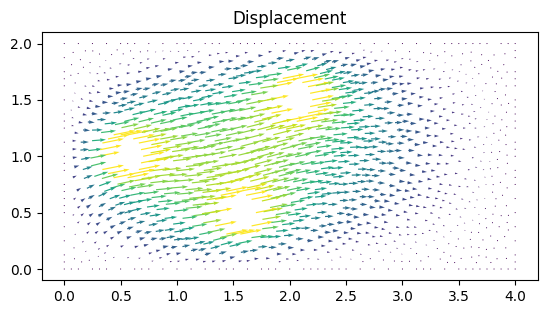

In [103]:
u1 = project(d, V)

# Plot solution
plt.figure()
plot(u1, title="Displacement")

plt.show()

**Update mesh**

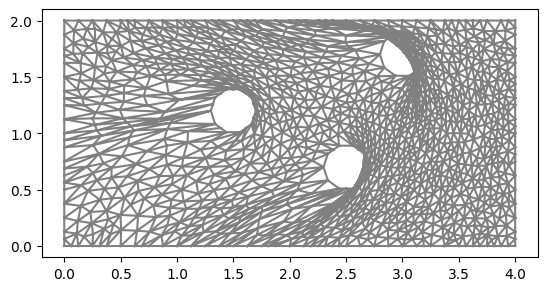

In [104]:
ALE.move(mesh, d)
plt.figure()
plot(mesh)
plt.show()

# **Discussion**

A Elasticity equation was solved with a finite element method.

### 2. Elasticity model

When the cylinder moves inside the channel, the elastic mesh responds as we would expect:
* The mesh is compressed in front of the cylinder (in the direction of motion),
* Stretched behind it, as it attempts to restore its shape.
* This behavior mimics how a real elastic material would respond to a moving obstacle.

This deformation is visable near the cylinder boundaries, and decays quickly with distance into the mesh.

#### Changing Young's modulus and Poisson's ratio

Varying Young's modulus $E$ in the simulation, for instance from $E = 10^{10}$ down to $E = 10^4$, surprisingly does not seem to cause any noticeable change in the resulting deformation plots. Even increasing it up to $E = 10^{15}$ results in no visual change. This suggests that either the range of $E$ used is not influential relative to the applied forces.

In contrast, changing the Poisson's ratio $\nu$ has a much more dramatic effect. Increasing it from a standard value like $\nu = 0.3$ (typical for steel) to $\nu = 0.499$, which is nearly incompressible, causes the simulation to become unstable or even break down. The mesh becomes tangled and/or distorted.

On the other hand, decreasing Poisson's ratio to a much lower value like $\nu = 0.1$ leads to minimal visual differences, similar to the Young's modulus experiments. Lowering both $E$ and $\nu$ at the same time seems again to have no significant impact.


#### Changing the movement of the cylinders

Increasing the displacement of the cylinders has a clear effect on the deformation of the elastic mesh. For instance, increasing the x-direction movement from $0.5$ to $1.0$, and introducing a y-direction displacement of $0.2$ causes the mesh to wrap around the cylinders. This suggests that the observed deformations are no longer fully captured by a 2D model, as the material begins to fold or wrap in ways that are not physically possible in a two-dimensional setting. In reality, such interactions would require a 3D structure, since overlapping or "z-direction" displacements cannot be accurately represented in two dimensions (only x and y coordinates).

#### Conclusion:

For this model to produce physically meaningful results, the mesh must represent a reasonably elastic material, i.e. the Poisson's ratio should be kept within realistic values, such as $\nu = 0.3$, typical for materials like steel. Additionally, the prescribed displacements should remain small relative to the size of the domain. Too big displacements results in too large mesh distortions, or deformation patterns that are not physically possible in a two-dimensional setting.
